# League of Legends - Per-role Match Outcome Prediction

**Goal.** Given a single player's end-of-game statistics, predict whether their
team won, and identify which quantifiable factors matter most for winning.

**Why per role.** The drivers of victory differ by position (a Support's value
is not measured the same way as a Bot carry's), so we train one model per role:
Top, Jungle, Mid, Bot, Support.

This notebook is a thin narrative layer over the `lolwin` package in `src/`.
All heavy lifting (loading, feature engineering, training, evaluation) lives in
tested modules; here we just tell the story and show the results.

In [1]:
import sys
from pathlib import Path

# Make the local package importable without installing it.
sys.path.insert(0, str(Path.cwd() / "src"))

import pandas as pd

from lolwin import ROLES
from lolwin.data import load_players
from lolwin.features import (
    LEAKY_COLUMNS,
    add_derived_features,
    build_feature_matrix,
    mutual_information,
)
from lolwin.model import train_all_roles
from lolwin.evaluate import evaluate_all, format_results

pd.set_option("display.max_columns", None)

## 1. Load and inspect the data

The dataset is three CSV files placed in a git-ignored `data/` folder (see the
README for download instructions). We work with `game_players_stats.csv`: one
row per (game, player), 10 players per game.

We use `sample_frac` here only to keep the notebook snappy. The reported metrics
at the end come from the full-data CLI run; rerun `python train.py` for those.

In [2]:
players = load_players(sample_frac=0.2, random_state=42)
print(f"rows: {len(players):,} | games: {players['game_id'].nunique():,}")
players.head()

rows: 74,900 | games: 7,490


,game_id,player_id,player_name,team_id,team_name,team_acronym,role,win,game_length,champion_name,team_kills,tower_kills,inhibitor_kills,dragon_kills,herald_kills,baron_kills,player_kills,player_deaths,player_assists,total_minions_killed,gold_earned,level,total_damage_dealt,total_damage_dealt_to_champions,total_damage_taken,wards_placed,largest_killing_spree,largest_multi_kill
0,18,11,1220,3,LinGan e-Sports,LGE,Mid,0,1691,Jayce,8,3,0,1,0,0,1,2,2,289,11560,16,195705,12608,12493,15,0,1
1,18,13,XMJ,2,FunPlus Phoenix Blaze,FPB,Jungle,1,1691,Rek'Sai,18,11,1,4,1,1,6,0,5,210,13293,16,188879,11616,26652,19,6,2
2,18,20,Alun,3,LinGan e-Sports,LGE,Top,0,1691,Pantheon,8,3,0,1,0,0,2,3,4,248,11530,15,134587,13709,22183,13,2,1
3,18,16,fortunate,3,LinGan e-Sports,LGE,Jungle,0,1691,Elise,8,3,0,1,0,0,1,6,3,123,8675,13,107499,7233,17290,31,0,1
4,18,17,Cepted,2,FunPlus Phoenix Blaze,FPB,Mid,1,1691,Syndra,18,11,1,4,1,1,6,1,7,374,17601,18,278499,25271,10488,25,4,1


### Class balance

A first, cheap sanity check: is the target balanced? If it were skewed we would
have to worry about accuracy being misleading and consider class weights.

In [3]:
print("Win rate:", round(players["win"].mean(), 4), "(0.5 == perfectly balanced)")
players["win"].value_counts()

Win rate: 0.5 (0.5 == perfectly balanced)


win
0    37450
1    37450
Name: count, dtype: int64

## 2. Data leakage: the most important decision in this project

The raw table contains **team-level objective columns** shared by all five
players of a team: `tower_kills`, `inhibitor_kills`, `team_kills`,
`baron_kills`, `dragon_kills`, `herald_kills`.

These almost *define* the result. By the rules of the game you cannot win
without destroying the enemy Nexus, which requires taking towers and
inhibitors. Their univariate ROC-AUC against `win` is near-perfect:

In [4]:
from sklearn.metrics import roc_auc_score

leak_auc = {c: roc_auc_score(players["win"], players[c]) for c in LEAKY_COLUMNS}
pd.Series(leak_auc, name="univariate ROC-AUC").sort_values(ascending=False)

tower_kills        0.986734
inhibitor_kills    0.967718
team_kills         0.909902
baron_kills        0.854357
dragon_kills       0.833834
herald_kills       0.646938
Name: univariate ROC-AUC, dtype: float64

`tower_kills` alone reaches ~0.99 AUC. Feeding these in would let the model
"cheat" and would answer the wrong question. The whole point is **what should a
*player* focus on**, so the `lolwin` package never uses them
(`features.LEAKY_COLUMNS` documents the exclusion, and a unit test enforces it).

We model only on **player-performance columns** and features derived from them.

## 3. Feature engineering + mutual-information selection

We add gameplay-motivated derived features (KDA ratio, assists share, gold per
level/kill, killing-spree concentration, log-gold) and then rank every candidate
with **mutual information**, which captures non-linear dependence (the link
between deaths and winning is far from linear). Features below a small MI floor
are dropped as noise.

In [5]:
df = add_derived_features(players)
mi = mutual_information(df, [c for c in df.columns
                             if df[c].dtype.kind in "if"
                             and c not in LEAKY_COLUMNS
                             and c not in ("win", "game_id", "player_id", "team_id", "game_length")])
mi.head(20)

,feature,mi_score
0,kda_ratio,0.388349
1,player_assists,0.198175
2,player_deaths,0.167814
3,assists_share,0.125387
4,largest_killing_spree,0.090768
5,player_kills,0.079779
6,spree_per_kill,0.075747
7,gold_per_kill,0.068268
8,log_gold,0.057788
9,gold_earned,0.056492


`build_feature_matrix` wraps "add derived features + select by MI + strip any
leaky/identifier column" into one call. This is exactly what the CLI uses.

In [6]:
df, features = build_feature_matrix(players)
print(f"Selected {len(features)} features:")
features

Selected 15 features:


['kda_ratio',
 'player_assists',
 'player_deaths',
 'assists_share',
 'largest_killing_spree',
 'player_kills',
 'spree_per_kill',
 'gold_per_kill',
 'gold_earned',
 'log_gold',
 'largest_multi_kill',
 'gold_per_level',
 'level',
 'total_damage_dealt_to_champions',
 'total_damage_taken']

## 4. Per-role training (leakage-free)

What the original version got wrong and we fixed:

1. **Hyperparameters were chosen on the test set.** Now they are chosen by
   grouped, stratified K-fold cross-validation on the **training data only**,
   scored by ROC-AUC. The test set is touched once, for the final report.
2. **Early stopping used the test set as its eval set.** Removed.
3. **Same-game leakage.** We split by `game_id` (`GroupShuffleSplit`) so the two
   opposing players of a game never straddle the train/test boundary.
4. **Accuracy only.** We now report ROC-AUC and F1 too.
5. **Reproducibility.** All seeds fixed.

We pass `tune=False` here for speed; the CLI run does the full grid search.

In [7]:
models = train_all_roles(df, features, roles=ROLES, tune=False, verbose=True)

Training role: Top


  best params: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8}
  cv ROC-AUC : nan
Training role: Jungle


  best params: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8}
  cv ROC-AUC : nan
Training role: Mid


  best params: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8}
  cv ROC-AUC : nan
Training role: Bot


  best params: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8}
  cv ROC-AUC : nan
Training role: Support


  best params: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8}
  cv ROC-AUC : nan


## 5. Held-out evaluation

Each role is scored on its own held-out test set (never seen during tuning or
fitting). `Overall` is the sample-size-weighted average.

In [8]:
results = evaluate_all(models)
results

,role,n_test,accuracy,roc_auc,f1
0,Top,2996,0.875834,0.948757,0.876165
1,Jungle,2996,0.891856,0.961537,0.891928
2,Mid,2996,0.895194,0.962962,0.894347
3,Bot,2996,0.901869,0.969978,0.902326
4,Support,2996,0.890521,0.958768,0.891821
5,Overall,14980,0.891055,0.960400,0.891317


In [9]:
print(format_results(results))

| Role | n_test | Accuracy | ROC-AUC | F1 |
|---|---|---|---|---|
| Top | 2996 | 0.8758 | 0.9488 | 0.8762 |
| Jungle | 2996 | 0.8919 | 0.9615 | 0.8919 |
| Mid | 2996 | 0.8952 | 0.9630 | 0.8943 |
| Bot | 2996 | 0.9019 | 0.9700 | 0.9023 |
| Support | 2996 | 0.8905 | 0.9588 | 0.8918 |
| Overall | 14980 | 0.8911 | 0.9604 | 0.8913 |


> **Note on numbers.** The table above uses a 20% sample and untuned models, so
> it is slightly below the headline figures. The README cites the **full-data,
> tuned** run (`python train.py`): Overall accuracy ~0.889, ROC-AUC ~0.960,
> F1 ~0.890. Per-role AUC ranges ~0.954 (Top) to ~0.966 (Bot).

## 6. Interpretability with SHAP

Which features push a prediction toward "win"? We use SHAP on the Bot model as
an example. KDA-related and gold features dominate, which matches intuition and
the mutual-information ranking.

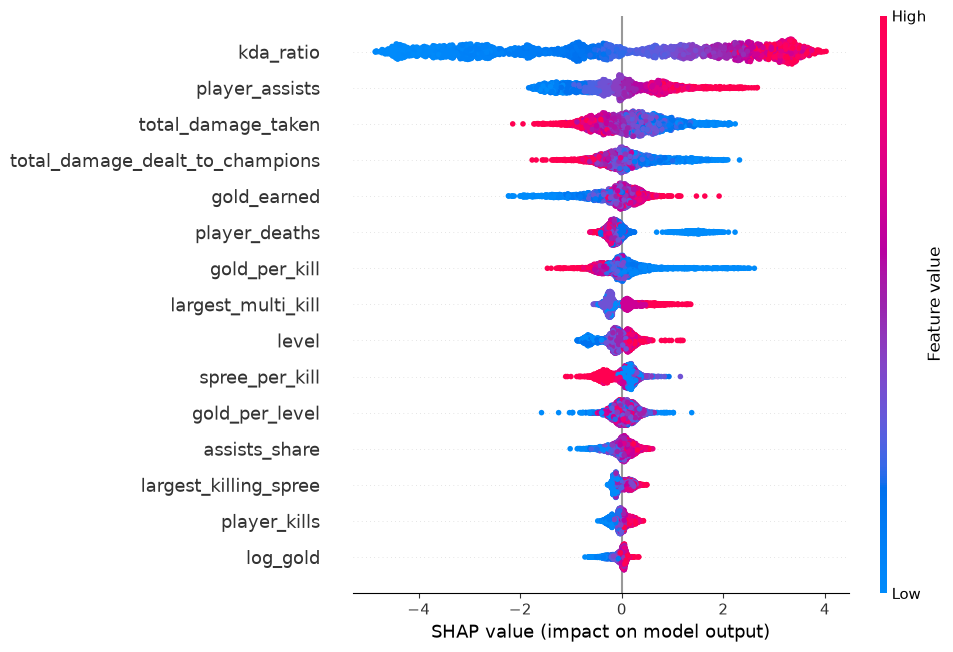

In [10]:
import shap

bot = models["Bot"]
X_bot = bot.X_test
explainer = shap.TreeExplainer(bot.model)
shap_values = explainer(X_bot)

shap.plots.beeswarm(shap_values, max_display=15)

In [11]:
import numpy as np

shap_summary = (
    pd.DataFrame(
        {"feature": features, "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)}
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
shap_summary

,feature,mean_abs_shap
0,kda_ratio,2.272433
1,player_assists,0.730452
2,total_damage_taken,0.562151
3,total_damage_dealt_to_champions,0.423484
4,gold_earned,0.389948
5,player_deaths,0.354516
6,gold_per_kill,0.334757
7,largest_multi_kill,0.265295
8,level,0.240177
9,spree_per_kill,0.223667


## 7. Takeaways

- A player's own end-of-game stats predict the team result with ~0.89 accuracy
  and ~0.96 ROC-AUC per role, **without** any team-objective leakage.
- The strongest, most actionable signals are **KDA ratio, deaths, assists and
  gold efficiency**: surviving (low deaths) and converting kill participation
  into a gold lead are what correlate most with winning.
- Per-role models are marginally better than one global model because the value
  of each statistic depends on the role.

See the README's "Limitations and how I would improve this" section for the
honest caveats (post-game stats are correlational, not a real-time predictor).